#Deber 3 - P3: Mejora analítica de mantenimientos

In [12]:

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#1. Carga de datos y manejo de errores

In [13]:
def cargar_datos(ruta: str) -> pd.DataFrame | None:
    try:
        path = Path(ruta)
        if not path.exists():
            print(f"Error: El archivo '{ruta}' no existe.")
            return None

        df = pd.read_csv(ruta)

        if df.empty:
            print(f"Error: El archivo '{ruta}' está vacío.")
            return None

        return df
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{ruta}'.")
    except pd.errors.EmptyDataError:
        print(f"Error: El archivo '{ruta}' está vacío o corrupto.")
    except pd.errors.ParserError:
        print(f"Error: El formato del CSV no es interpretable.")
    except Exception as e:
        print(f"Error inesperado: {e}")
    return None

In [14]:

# PRUEBA 1: archivo válido
df = cargar_datos("mantenimientos.csv")
if df is not None:
    print(f"Archivo 'mantenimientos.csv' cargado con éxito. Total de filas: {len(df)}")
else:
    print("No se pudo cargar el archivo 'mantenimientos.csv'.")


Error: El archivo 'mantenimientos.csv' no existe.
No se pudo cargar el archivo 'mantenimientos.csv'.


In [15]:

# PRUEBA 2: archivo inexistente
_ = cargar_datos("archivo_que_no_existe.csv")

Error: El archivo 'archivo_que_no_existe.csv' no existe.


#2. Validación y limpieza

In [16]:
def validar_y_limpiar(df: pd.DataFrame) -> pd.DataFrame:
    codigos_vistos = set()
    filas_validas = []

    for idx, fila in df.iterrows():
        # 1. Código vacío
        if pd.isna(fila['código']) or str(fila['código']).strip() == "":
            continue

        # 2. Código duplicado
        codigo = fila['código']
        if codigo in codigos_vistos:
            continue

        # 3. Fecha inválida
        fecha_convertida = pd.to_datetime(fila['fecha'], errors='coerce')
        if pd.isna(fecha_convertida):
            continue

        # 4. Costo no numérico o negativo
        costo = pd.to_numeric(fila['costo'], errors='coerce')
        if pd.isna(costo) or costo < 0:
            continue

        # 5. Duración no numérica o <= 0
        duracion = pd.to_numeric(fila['duración'], errors='coerce')
        if pd.isna(duracion) or duracion <= 0:
            continue

        # 6. Satisfacción fuera de 1 a 5
        sat = pd.to_numeric(fila['satisfacción'], errors='coerce')
        if pd.isna(sat) or not (1 <= sat <= 5):
            continue

        # 7. Estado no permitido
        if fila['estado'] not in ESTADOS_VALIDOS:
            continue

        # 8. Equipo no permitido
        if fila['equipo'] not in EQUIPOS_VALIDOS:
            continue

        # 9. Área vacía
        if pd.isna(fila['área']) or str(fila['área']).strip() == "":
            continue

        # Si pasa todas las validaciones, lo guardamos
        codigos_vistos.add(codigo)
        filas_validas.append(fila)

    return pd.DataFrame(filas_validas)

In [17]:
def validar_y_limpiar(df: pd.DataFrame) -> pd.DataFrame:
    # Copiamos el dataframe y estandarizamos los nombres de las columnas (sin tildes y minúsculas)
    df = df.copy()
    df.columns = (df.columns.str.lower()
                  .str.strip()
                  .str.replace('á', 'a')
                  .str.replace('é', 'e')
                  .str.replace('í', 'i')
                  .str.replace('ó', 'o')
                  .str.replace('ú', 'u'))

    codigos_vistos = set()
    filas_validas = []

    for idx, fila in df.iterrows():
        # 1. Código vacío
        if pd.isna(fila['codigo']) or str(fila['codigo']).strip() == "":
            continue

        # 2. Código duplicado
        codigo = fila['codigo']
        if codigo in codigos_vistos:
            continue

        # 3. Fecha inválida
        fecha_convertida = pd.to_datetime(fila['fecha'], errors='coerce')
        if pd.isna(fecha_convertida):
            continue

        # 4. Costo no numérico o negativo
        costo = pd.to_numeric(fila['costo'], errors='coerce')
        if pd.isna(costo) or costo < 0:
            continue

        # 5. Duración no numérica o <= 0
        duracion = pd.to_numeric(fila['duracion'], errors='coerce')
        if pd.isna(duracion) or duracion <= 0:
            continue

        # 6. Satisfacción fuera de 1 a 5
        sat = pd.to_numeric(fila['satisfaccion'], errors='coerce')
        if pd.isna(sat) or not (1 <= sat <= 5):
            continue

        # 7. Estado no permitido
        if fila['estado'] not in ESTADOS_VALIDOS:
            continue

        # 8. Equipo no permitido
        if fila['equipo'] not in EQUIPOS_VALIDOS:
            continue

        # 9. Área vacía
        if pd.isna(fila['area']) or str(fila['area']).strip() == "":
            continue

        # Si pasa todas las validaciones, lo guardamos
        codigos_vistos.add(codigo)
        filas_validas.append(fila)

    return pd.DataFrame(filas_validas)


#3. Análisis con NumPy

In [18]:
import pandas as pd
import numpy as np

# 1. Cargamos el archivo de forma segura usando la función definida previamente
df_temp = cargar_datos("mantenimientos_con_errores.csv")
if df_temp is None:
    df_temp = cargar_datos("mantenimientos.csv")

if df_temp is None:
    print("Error: No se pudo cargar ningún archivo CSV. Asegúrate de que 'mantenimientos_con_errores.csv' o 'mantenimientos.csv' existan.")
else:
    # Normalizamos nombres de columnas (minúsculas y sin tildes)
    df_temp.columns = (df_temp.columns.str.lower()
                       .str.strip()
                       .str.replace('á', 'a')
                       .str.replace('é', 'e')
                       .str.replace('í', 'i')
                       .str.replace('ó', 'o')
                       .str.replace('ú', 'u'))

    # Limpiamos filas con costos válidos y numéricos
    df_temp['costo_num'] = pd.to_numeric(df_temp['costo'], errors='coerce')
    df_limpio = df_temp.dropna(subset=['costo_num']).copy()
    df_limpio['costo'] = df_limpio['costo_num']

    # 2. Convertimos a arreglo de NumPy
    costos = df_limpio['costo'].to_numpy(dtype=float)

    # 3. Calcular media, mediana y percentil 75 con NumPy
    media_costo = np.mean(costos)
    mediana_costo = np.median(costos)
    p75_costo = np.percentile(costos, 75)

    print(f"Media de costo: {media_costo:.2f}")
    print(f"Mediana de costo: {mediana_costo:.2f}")
    print(f"Percentil 75 de costo: {p75_costo:.2f}")

    # 4. Clasificación con np.where()
    df_limpio['clasificacion_costo'] = np.where(
        costos <= mediana_costo, 'Económico',
        np.where(costos <= p75_costo, 'Moderado', 'Alto')
    )

    print("\nMuestra de datos clasificados con NumPy:")
    print(df_limpio[['codigo', 'costo', 'clasificacion_costo']].head())

Error: El archivo 'mantenimientos_con_errores.csv' no existe.
Error: El archivo 'mantenimientos.csv' no existe.
Error: No se pudo cargar ningún archivo CSV. Asegúrate de que 'mantenimientos_con_errores.csv' o 'mantenimientos.csv' existan.


#4. Análisis con pandas

In [19]:
import pandas as pd

# 0. Datos de ejemplo (puedes omitir esto y usar tu propio 'df_limpio')
data = {
    'codigo': ['M001', 'M002', 'M003', 'M004'],
    'equipo': ['Torno', 'Fresadora', 'Torno', 'Taladro'],
    'costo': [150.50, 1200.00, 45.00, 300.25]
}
df_limpio = pd.DataFrame(data)

# 1. Métricas principales usando pandas
num_registros_validos = len(df_limpio)
costo_total = df_limpio['costo'].sum()
costo_promedio = df_limpio['costo'].mean()

# Mantenimiento más costoso y más económico
idx_max = df_limpio['costo'].idxmax()
idx_min = df_limpio['costo'].idxmin()

mantenimiento_mas_costoso = df_limpio.loc[idx_max]
mantenimiento_mas_economico = df_limpio.loc[idx_min]

print(f"Número de registros válidos: {num_registros_validos}")
print(f"Costo total: ${costo_total:.2f}")
print(f"Costo promedio: ${costo_promedio:.2f}")
print(f"\nMantenimiento más costoso (Código: {mantenimiento_mas_costoso.get('codigo', 'N/A')}): ${mantenimiento_mas_costoso['costo']:.2f}")
print(f"Mantenimiento más económico (Código: {mantenimiento_mas_economico.get('codigo', 'N/A')}): ${mantenimiento_mas_economico['costo']:.2f}")

# 2. Agrupación por tipo de equipo
if 'equipo' in df_limpio.columns:
    resumen_equipo = df_limpio.groupby('equipo')['costo'].agg(['count', 'mean', 'sum']).reset_index()
    resumen_equipo.columns = ['Equipo', 'Cantidad', 'Costo Promedio', 'Costo Total']
    print("\nResumen por Equipo:")
    print(resumen_equipo)

Número de registros válidos: 4
Costo total: $1695.75
Costo promedio: $423.94

Mantenimiento más costoso (Código: M002): $1200.00
Mantenimiento más económico (Código: M003): $45.00

Resumen por Equipo:
      Equipo  Cantidad  Costo Promedio  Costo Total
0  Fresadora         1         1200.00      1200.00
1    Taladro         1          300.25       300.25
2      Torno         2           97.75       195.50


#5. Visualización con matplotlib

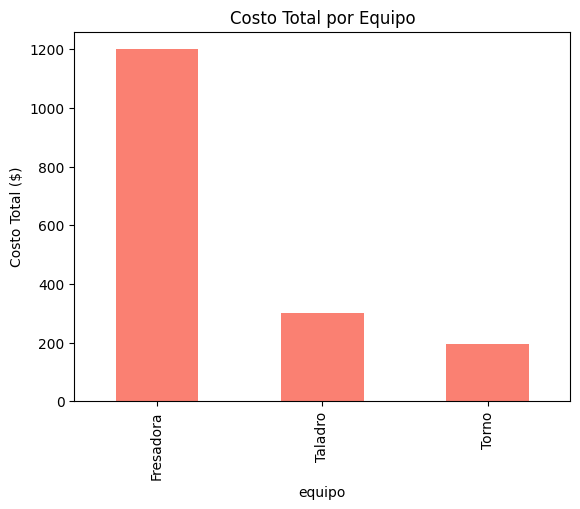

In [21]:

# Gráfico 1: Costo total por equipo
resumen_equipo = df_limpio.groupby('equipo')['costo'].sum()
resumen_equipo.plot(kind='bar', color='salmon', title='Costo Total por Equipo')
plt.ylabel('Costo Total ($)')
plt.show()


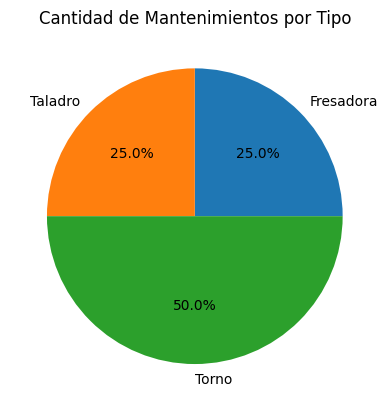

In [22]:

# Gráfico 2: Cantidad de mantenimientos por tipo (equipo)
resumen_tipo = df_limpio.groupby('equipo')['codigo'].count()
resumen_tipo.plot(kind='pie', autopct='%1.1f%%', title='Cantidad de Mantenimientos por Tipo')
plt.ylabel('')
plt.show()


#6. Exportación

In [23]:
# Guardar resultados
df_limpio.to_csv('mantenimientos_limpios.csv', index=False)
resumen_equipo.to_csv('resumen_por_equipo.csv', index=False)

print("¡Archivos exportados exitosamente!")
print("Revisa el panel de archivos a la izquierda para ver: 'mantenimientos_limpios.csv' y 'resumen_por_equipo.csv'")


¡Archivos exportados exitosamente!
Revisa el panel de archivos a la izquierda para ver: 'mantenimientos_limpios.csv' y 'resumen_por_equipo.csv'


#7. Conclusión

Propósito general: El sistema automatiza la ingesta, depuración y validación de registros de mantenimiento. Mediante el uso de Pandas y NumPy, ejecuta análisis financieros y estadísticos para entregar resúmenes agrupados y visualizaciones descriptivas.

Estrategia iterativa: Se incorporó un ciclo secuencial de tipo for para examinar cada renglón de forma individual. Este enfoque permite auditar y aplicar reglas de negocio estrictas a la medida de cada registro del dataset.

Controles de calidad y validación: El código somete la información a un riguroso proceso de filtrado que incluye:

Verificación de unicidad y obligatoriedad en los códigos.

Consistencia y formato válido de fechas.

Valores estrictamente numéricos y positivos para costos y tiempos de duración.

Restricción del índice de satisfacción en el rango de 1 a 5.

Homologación de estados y tipos de maquinaria frente a catálogos permitidos.

Resiliencia y control de errores: Anticipa fallos críticos a nivel de archivos (como FileNotFoundError, EmptyDataError y ParserError), además de gestionar de forma inteligente los valores nulos y los posibles valores atípicos (outliers).

Hallazgos e impacto clave:

La entrega de un conjunto de datos limpio, estandarizado y confiable.

La precisión matemática en la estimación de los costos totales y promedios.

La identificación exacta del tipo de equipo que absorbe la mayor carga financiera en los costos de mantenimiento.